# Heterogeneous multipopulation Hawkes: pipeline theory vs simulation

Slim comparison notebook for the **heterogeneous-population** theory
`theories/multipopulation_test.theory.py`, in the same style as
`pipeline_quad_expg_sim_compare.ipynb`.  The theory side is a single
call to `pipeline.compute_cumulants(...)`; the simulation side uses a
new multipopulation numba simulator (`models/hawkes_sim_multipop_numba.py`)
with per-pair exponential filters that match the matrix-indexed kernels
(`gEE[i,j]`, `gEI[i,j]`, `gIE[i,j]`, `gII[i,j]`) in the theory file.

**What this verifies**
- Mean-field rates from the pipeline match per-neuron firing rates
  in the simulator.
- The MSR-JD tree-level $C^{(2)}(\tau)$ slice between two selected
  external fields matches the simulator's factorial covariance.

**Workflow**
1. Edit the `fundamental` dict in the configuration cell.
2. Pick which two external fields to compare (`external_fields`).
3. Run all cells.

The theory file already knows the structure (2 populations E and I,
size 2 each, matrix-indexed weights and kernels) — only numerical
values come from `fundamental`.

## 1. Setup

In [1]:
%display latex
%matplotlib inline

import os, sys, time, importlib, importlib.util
import numpy as np
import matplotlib.pyplot as plt

import os, sys
# --- depth-robust repo root: walk up until we find the 'pipeline' package ---
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ so relative data paths resolve as before

# Shared demo engine (load → run → plot)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
import daedalus as dd

# Pipeline (theory side)
from pipeline import compute_cumulants

# Simulation side — new multipop simulator + flat-index helper
from models.hawkes_sim_multipop_numba import (
    sim_hawkes_multipop_numba,
    build_sim_arrays,
    flat_index_of,
)
from models.cumulant_estimator import compute_kpoint_slice

## 2. Configuration

`fundamental` provides numerical values for every parameter declared
in `multipopulation_test.theory.py`.  Vector params (`tauE`, `aE`,
`EmE`, `tauI`, `aI`, `EmI`) are length-2 (one per neuron in the
population).  Matrix params (`wEE`, `wEI`, `wIE`, `wII`, `taugEE`,
`taugEI`, `taugIE`, `taugII`) are 2×2 (`row = post-population index,
col = pre-population index`).

In [2]:
fundamental = {
    'tauE':   [10.0, 9.5],
    'tauI':   [8.0, 7.0],
    'EmE':    [0.7, 0.72],
    'EmI':    [0.4, 0.42],
    'aE':     [0.37, 0.41],
    'aI':     [0.23, 0.28],
    'wEE':    [[0.25, 0.22], [0.21, 0.19]],
    'wEI':    [[0.12, 0.15], [0.13, 0.10]],
    'wIE':    [[0.19, 0.17], [0.15, 0.12]],
    'wII':    [[0.12, 0.13], [0.14, 0.15]],
    'taugEE': [[4.0, 4.0], [3.0, 3.0]],
    'taugEI': [[2.0, 1.0], [1.0, 3.0]],
    'taugIE': [[5.0, 6.0], [2.0, 1.0]],
    'taugII': [[1.5, 1.2], [1.1, 1.0]],
}

# k-point cumulant + loop order (theory side)
k        = 2
max_ell  = 0
# External fields are 1-based (pop, index_within_pop).  The pipeline
# maps user-facing names like 'nE' to the internal fluctuation
# 'dnE' automatically.
external_fields = [('nE', 1), ('nE', 2)]

# τ grid (theory + sim share this)
tau_max  = 50.0
tau_step = 0.5

# Pipeline parallelism — fanned across enumeration (step [5]) and
# Phase J τ-grid evaluation (step [7]).  PARALLEL=False forces
# serial (useful for debugging the heterogeneous path).
PARALLEL  = True
N_WORKERS = None

# Simulation knobs — note the multipop simulator is more expensive
# per Euler step than the single-tau-g version (N×N filter updates
# instead of N), so a smaller default T_sim than the legacy
# notebooks is appropriate.
N_RUNS   = 4
T_sim    = float(2_000_000)
dt_sim   = 0.01            # Euler step (time units shared everywhere)
dt_bin   = 0.25            # binning resolution for the cumulant estimator

print(f'k={k}, max_ell={max_ell}, external_fields={external_fields}')
print(f'tau_max={tau_max}, tau_step={tau_step}')
print(f'PARALLEL={PARALLEL}, N_WORKERS={N_WORKERS}')
print(f'N_RUNS={N_RUNS}, T_sim={T_sim:.0g}, dt_sim={dt_sim}, dt_bin={dt_bin}')

k=2, max_ell=0, external_fields=[('nE', 1), ('nE', 2)]
tau_max=50.0000000000000, tau_step=0.500000000000000
PARALLEL=True, N_WORKERS=None
N_RUNS=4, T_sim=2e+06, dt_sim=0.0100000000000000, dt_bin=0.250000000000000


## 3. Load the theory file

Read `theories/multipopulation_test.theory.py` and build the model
dict.  The theory file already declares all the structure (E and I
populations of size 2 each, the matrix-indexed kernels, the action,
and the mean-field equations).

In [3]:
THEORY_NAME = 'multipopulation_test'

# Load the theory through the shared engine (theories/<name>.theory.py).
model, theory_mod = dd.load_theory(THEORY_NAME)

print(f'Loaded theory: {model["name"]!r}')
print(f'Populations: {[(p["name"], p["size"]) for p in model["populations"]]}')
print(f'Fields (physical): '
      f'{[f["name"] for f in model["physical_fields"]]}')
print(f'Kernels: {[k["name"] for k in model["kernels"]]}')

Loaded theory: 'Multipopulation Test'
Populations: [('E', 2), ('I', 2)]
Fields (physical): ['dnE', 'dvE', 'dnI', 'dvI']
Kernels: ['gEE', 'gEI', 'gIE', 'gII']


## 4. Theory side — one pipeline call

Runs the full MSR-JD chain: FieldTheory.expand → symbolic propagator
K → solve_mean_field → numerical poles + residues (cofactor-adjugate
path for the rich heterogeneous case) → diagram enumeration → Phase
J τ-grid integration.

The slow step is `K_det_sr.numerator()` — Sage's canonicalization of
the 8×8 symbolic determinant takes ~3 minutes the first time.
Subsequent runs with the same `(model, taylor_order)` reuse the
cached symbolic propagator but still re-run pole/residue extraction
because those depend on `num_params`.

In [4]:
t0 = time.perf_counter()

# Theory side, through the shared engine.  Same k / max_ell / external_fields /
# fundamental / τ-grid / parallelism as before — dd.run just forwards them to
# pipeline.compute_cumulants and returns the SAME result dict.
cfg = dd.Config(
    k               = k,
    max_ell         = max_ell,
    external_fields = external_fields,
    fundamental     = fundamental,
    tau_max         = tau_max,
    tau_step        = tau_step,
    parallel        = PARALLEL,
    verbose         = True,
)
th = dd.run(model, cfg, theory_mod)

print(f'\nTheory side took {time.perf_counter() - t0:.1f}s')

# ── Legacy-name shim — downstream sim / diagnostic / plot cells unchanged ──
tau_grid_th    = th['tau_grid']
C_theory_total = th['C_tau'].real
C_by_ell       = th['C_tau_by_ell']
C_theory_tree  = (C_by_ell[0].real if 0 in C_by_ell
                  else np.zeros_like(C_theory_total))
C_theory_loop  = C_theory_total - C_theory_tree

# Mean-field accessor: mf['nE', 1] = nE*_1, etc.  Saddles are per-pop
# sized (length 2 each for the multipop theory).
mf_values = th['mf_values']
print('\nMean-field saddles:')
for name, vals in mf_values.items():
    print(f'  {name!r:8} = {vals}')

print(f'\nTotal diagrams: {len(th["diagrams"])}')
n_per_ell = {ell: sum(1 for r in th['diagrams'] if r['ell'] == ell)
             for ell in sorted({r['ell'] for r in th['diagrams']})}
for ell, n_d in n_per_ell.items():
    print(f'    ell={ell}: {n_d} diagrams')

[1/7] FieldTheory.expand (taylor_order=2)...


[expand-cache] hit at order=2 (exact, no filter)
=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM
      vtypes: 0, sources: 4 (NoiseSourceType: 0)

      ── MF action (bigrade ≤1 in each index; vanishes at saddle) ──
      bigrade (1, 0):
        vEt1  *  (-nEstar1*wEE11*z_gEE_1_1 - nEstar2*wEE12*z_gEE_1_2 + nIstar1*wEI11*z_gEI_1_1 + nIstar2*wEI12*z_gEI_1_2 - EmE1 + vEstar1)
        vEt2  *  (-nEstar1*wEE21*z_gEE_2_1 - nEstar2*wEE22*z_gEE_2_2 + nIstar1*wEI21*z_gEI_2_1 + nIstar2*wEI22*z_gEI_2_2 - EmE2 + vEstar2)
        vIt1  *  (-nEstar1*wIE11*z_gIE_1_1 - nEstar2*wIE12*z_gIE_1_2 + nIstar1*wII11*z_gII_1_1 + nIstar2*wII12*z_gII_1_2 - EmI1 + vIstar1)
        vIt2  *  (-nEstar1*wIE21*z_gIE_2_1 - nEstar2*wIE22*z_gIE_2_2 + nIstar1*wII21*z_gII_2_1 + nIstar2*wII22*z_gII_2_2 - EmI2 + vIstar2)
        nEt1  *  (-aE1*vEstar1 + nEstar1)


        vEt1·dvE1  *  (Dt*tauE1 + 1)
        vEt2·dvE2  *  (Dt*tauE2 + 1)
        vIt1·dvI1  *  (Dt*tauI1 + 1)
        vIt2·dvI2  *  (Dt*tauI2 + 1)
        vEt1·dnE1  *  (-wEE11*z_gEE_1_1)
        vEt1·dnE2  *  (-wEE12*z_gEE_1_2)
        vEt2·dnE1  *  (-wEE21*z_gEE_2_1)
        vEt2·dnE2  *  (-wEE22*z_gEE_2_2)
        vEt1·dnI1  *  (wEI11*z_gEI_1_1)
        vEt1·dnI2  *  (wEI12*z_gEI_1_2)
        vEt2·dnI1  *  (wEI21*z_gEI_2_1)
        vEt2·dnI2  *  (wEI22*z_gEI_2_2)
        vIt1·dnE1  *  (-wIE11*z_gIE_1_1)
        vIt1·dnE2  *  (-wIE12*z_gIE_1_2)
        vIt2·dnE1  *  (-wIE21*z_gIE_2_1)
        vIt2·dnE2  *  (-wIE22*z_gIE_2_2)
        vIt1·dnI1  *  (wII11*z_gII_1_1)
        vIt1·dnI2  *  (wII12*z_gII_1_2)
        vIt2·dnI1  *  (wII21*z_gII_2_1)
        vIt2·dnI2  *  (wII22*z_gII_2_2)
        nEt1·dvE1  *  (-aE1)
        nEt2·dvE2  *  (-aE2)
        nIt1·dvI1  *  (-aI1)
        nIt2·dvI2  *  (-aI2)
        nEt1·dnE1  *  (1)
        nEt2·dnE2  *  (1)
        nIt1·dnI1  *  (1)
        nI

[propagator] polynomial-fracfield: Q(ω) degree 16, 16 retarded pole(s) found.
[propagator] 16 retarded poles (Im(ω) > 0) — exact polynomial path:
  ω_1 = -0.000000 + (+0.080642) i
  ω_2 = +0.000000 + (+0.103364) i
  ω_3 = -0.000000 + (+0.125024) i
  ω_4 = +0.000000 + (+0.148296) i
  ω_5 = -0.000000 + (+0.168769) i
  ω_6 = +0.000000 + (+0.200609) i
  ω_7 = -0.000000 + (+0.261553) i
  ω_8 = +0.000000 + (+0.346158) i
  ω_9 = +0.001124 + (+0.500095) i
  ω_10 = -0.001124 + (+0.500095) i
  ω_11 = +0.000000 + (+0.662381) i
  ω_12 = -0.000000 + (+0.832901) i
  ω_13 = +0.000000 + (+0.909465) i
  ω_14 = -0.000003 + (+0.992793) i
  ω_15 = +0.000043 + (+0.999802) i
  ω_16 = -0.000040 + (+1.000264) i

      ── C_mats (residue matrix at each pole) ──
        rows (response): ['nEt1', 'nEt2', 'vEt1', 'vEt2', 'nIt1', 'nIt2', 'vIt1', 'vIt2']
        cols (physical): ['dnE1', 'dnE2', 'dvE1', 'dvE2', 'dnI1', 'dnI2', 'dvI1', 'dvI2']
      C_mats[0]  (residue at ω_1 = -0.0000+0.0806i):
        [0,0] = +1.2

      [phase_j] done in 1.64s

Done.  k=2, max_ell=0, 4 unique diagrams, 201 τ points.

  Phase wall summary (Σ = 4.3s):
    expand          1.42s  (32.9%)
    propagator      0.04s  ( 0.9%)
    mean_field      0.01s  ( 0.2%)
    poles           1.20s  (27.6%)
    diagrams        0.01s  ( 0.3%)
    classify        0.01s  ( 0.3%)
    phase_j         1.64s  (37.8%)

Theory side took 4.3s

Mean-field saddles:
  'nEstar' = [0.30204210909362245, 0.336051426661768]
  'vEstar' = [0.816330024577358, 0.8196376260043123]
  'nIstar' = [0.1113288719331994, 0.13168234619768343]
  'vIstar' = [0.48403857362260605, 0.4702940935631551]

Total diagrams: 4
    ell=0: 4 diagrams


## 5. Simulation side

Stacks both populations into a single flat 1-D array of N neurons
(E first, then I).  The simulator integrates the per-pair filter
ODE

$$\tau_{g,ij}\,\dot F_{ij} + F_{ij} = n_j(t)$$

for every (i, j) pair, then steps the membrane:

$$\tau_{v,i}\,\dot v_i = -v_i + E_i + \sum_j W_{ij} F_{ij}$$

where $W_{ij}$ is the signed coupling (E presyn: $+$, I presyn: $-$),
and spikes are Poisson-sampled with rate $\lambda_i = \max(a_i v_i, 0)$.

`build_sim_arrays` pulls per-neuron and per-pair arrays out of
`model` + `fundamental` + the pipeline's `mf_values`, so the
simulator initialisation stays in lockstep with whatever the
theory file declares.

In [5]:
import secrets as _secrets

arr = build_sim_arrays(model, fundamental, mf_values)
N           = arr['N']
tau_v       = arr['tau_v']
a_gain      = arr['a_gain']
E_drive     = arr['E_drive']
W           = arr['W']
tau_g_arr   = arr['tau_g']
v_init      = arr['v_init']
pop_offsets = arr['pop_offsets']

print(f'Stacked neuron count: N = {N}')
for pname, (start, size) in pop_offsets.items():
    print(f'  pop {pname!r}: flat indices [{start}, {start + size})')
print(f'tau_v   = {tau_v}')
print(f'a_gain  = {a_gain}')
print(f'E_drive = {E_drive}')
print(f'v_init  = {v_init}')
print(f'W (signed coupling matrix, shape {W.shape}):')
print(W)
print(f'tau_g (per-pair filter timescale):')
print(tau_g_arr)

Stacked neuron count: N = 4
  pop 'E': flat indices [0, 2)
  pop 'I': flat indices [2, 4)
tau_v   = [10.   9.5  8.   7. ]
a_gain  = [0.37 0.41 0.23 0.28]
E_drive = [0.7  0.72 0.4  0.42]
v_init  = [0.81633002 0.81963763 0.48403857 0.47029409]
W (signed coupling matrix, shape (4, 4)):
[[ 0.25  0.22 -0.12 -0.15]
 [ 0.21  0.19 -0.13 -0.1 ]
 [ 0.19  0.17 -0.12 -0.13]
 [ 0.15  0.12 -0.14 -0.15]]
tau_g (per-pair filter timescale):
[[4.  4.  2.  1. ]
 [3.  3.  1.  3. ]
 [5.  6.  1.5 1.2]
 [2.  1.  1.1 1. ]]


In [6]:
# Discretization
n_steps        = int(T_sim / dt_sim)
bin_size_steps = max(int(round(dt_bin / dt_sim)), 1)
dt_bin_eff     = bin_size_steps * dt_sim
n_bins         = n_steps // bin_size_steps
max_lag_bins   = int(tau_max / dt_bin_eff)
tau_sim_grid   = np.arange(-max_lag_bins, max_lag_bins + 1) * dt_bin_eff

# Map external_fields to flat sim indices for the cumulant estimator.
# external_fields uses the natural-name population (e.g. 'nE'), which
# flat_index_of strips to get the population label ('E').
pop_indices = [flat_index_of(model, pop_offsets, ef[0], ef[1])
               for ef in external_fields]
field_types = [ef[0] for ef in external_fields]
# compute_kpoint_slice internally normalises 'nE'/'nI'/'n' → 'dn',
# 'vE'/'vI'/'v' → 'dv', etc., so the natural names work directly.
print(f'External fields {external_fields} → flat sim indices {pop_indices}')

# JIT warmup — first numba call compiles the function (a few seconds).
_ = sim_hawkes_multipop_numba(
    int(1000), float(dt_sim),
    tau_v, a_gain, E_drive,
    W, tau_g_arr,
    v_init.copy(),
    int(bin_size_steps), int(100), int(0),
)
print('JIT warmup done.')

External fields [('nE', 1), ('nE', 2)] → flat sim indices [0, 1]


JIT warmup done.


In [7]:
# Run the full simulation N_RUNS times with independent seeds.
BASE_SEED = _secrets.randbits(31)
C_sim_runs   = []
rate_runs    = []
voltage_runs = []

t0 = time.perf_counter()
for run in range(N_RUNS):
    seed = int(BASE_SEED + run)
    binned_counts, voltage_bins, total_spikes = sim_hawkes_multipop_numba(
        int(n_steps), float(dt_sim),
        tau_v, a_gain, E_drive,
        W, tau_g_arr,
        v_init.copy(),
        int(bin_size_steps), int(n_bins), seed,
    )
    rate_runs.append([float(total_spikes[i]) / T_sim for i in range(N)])
    voltage_runs.append(voltage_bins.mean(axis=1))

    # k=2 single-axis slice: leg 0 pinned at t=0, leg 1 sweeps over τ.
    tau_run, C_run = compute_kpoint_slice(
        binned_counts, float(dt_bin_eff),
        [int(p) for p in pop_indices],
        [0, None], int(max_lag_bins),
        field_types=field_types,
        voltage_bins=voltage_bins,
    )
    C_sim_runs.append(C_run)
    print(f'  run {run+1}/{N_RUNS}: rates = '
          f'{[f"{r:.4f}" for r in rate_runs[-1]]}')

C_sim_runs    = np.array(C_sim_runs)
C_sim_mean    = C_sim_runs.mean(axis=0)
C_sim_sem     = C_sim_runs.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
rate_runs_arr = np.array(rate_runs)
rate_sim_mean = rate_runs_arr.mean(axis=0)
rate_sim_sem  = rate_runs_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
vmean_sim     = np.array(voltage_runs).mean(axis=0)

print(f'\nSimulation side took {time.perf_counter() - t0:.1f}s '
      f'({N_RUNS} runs × T={T_sim:.0g})')
print(f'  Sim mean rates (per neuron): {rate_sim_mean}')
# Build the theory-MF nstar vector in the SAME flat order as the sim,
# so the bar plot can compare them directly.
nstar_flat = np.zeros(N)
for pname, (start, size) in pop_offsets.items():
    saddle_key = f'n{pname}star'
    if saddle_key in mf_values:
        for i in range(size):
            nstar_flat[start + i] = mf_values[saddle_key][i]
print(f'  Theory n* (flat order):     {nstar_flat}')

  run 1/4: rates = ['0.3018', '0.3365', '0.1115', '0.1319']


  run 2/4: rates = ['0.3023', '0.3356', '0.1111', '0.1320']


  run 3/4: rates = ['0.3011', '0.3369', '0.1110', '0.1313']


  run 4/4: rates = ['0.3019', '0.3362', '0.1113', '0.1316']

Simulation side took 81.9s (4 runs × T=2e+06)
  Sim mean rates (per neuron): [0.30177925 0.3363085  0.11122175 0.13168925]
  Theory n* (flat order):     [0.30204211 0.33605143 0.11132887 0.13168235]


## 6. Theory vs simulation

Top-left: per-neuron firing rates (sim vs MF) — labels show which
population the neuron belongs to.  Right: the $C^{(2)}(\tau)$ slice
for the two external fields chosen above.  The simulation curve has
an across-run SEM band; the theory curve should lie within that band
if both pieces agree.

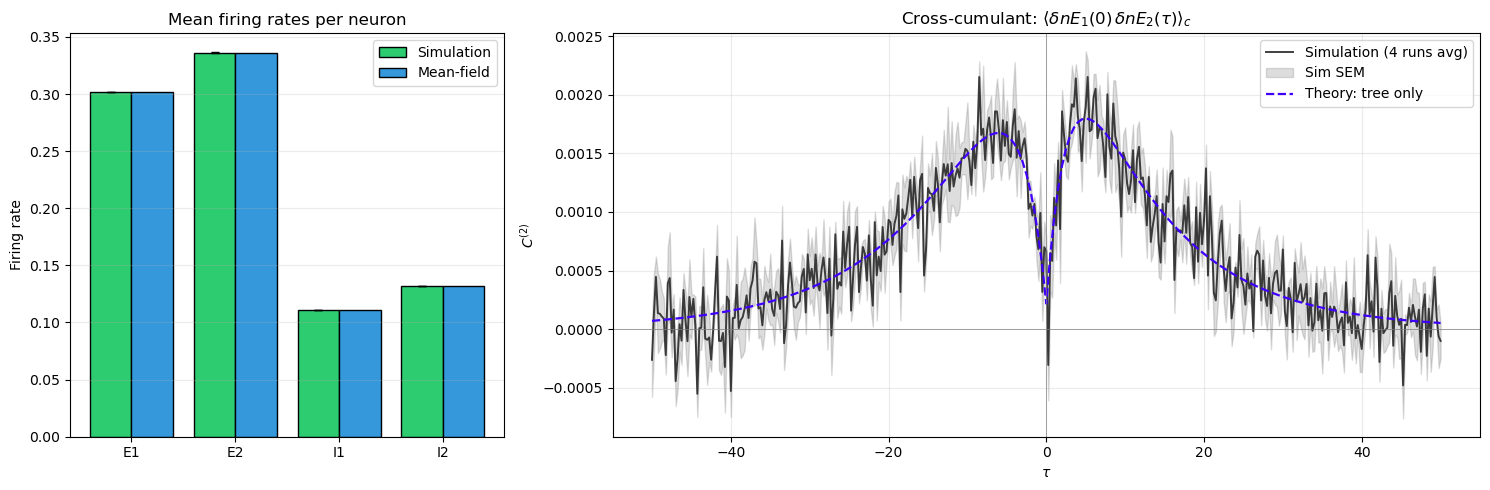

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5),
                         gridspec_kw={'width_ratios': [1, 2]})

# Per-neuron firing-rate bars (sim vs MF), grouped by population.
ax_bar = axes[0]
x = np.arange(N)
width = 0.4
ax_bar.bar(x - width/2, rate_sim_mean, width,
           yerr=rate_sim_sem, capsize=3,
           label='Simulation', color='#2ECC71', edgecolor='black')
ax_bar.bar(x + width/2, nstar_flat, width,
           label='Mean-field', color='#3498DB', edgecolor='black')
ax_bar.set_xticks(x)
tick_labels = []
for pname, (start, size) in pop_offsets.items():
    for i in range(size):
        tick_labels.append(f'{pname}{i+1}')
ax_bar.set_xticklabels(tick_labels)
ax_bar.set_ylabel('Firing rate')
ax_bar.set_title('Mean firing rates per neuron')
ax_bar.legend()
ax_bar.grid(True, axis='y', alpha=0.25)

# C^(2)(τ) slice
ax = axes[1]
ax.plot(tau_sim_grid, C_sim_mean, color='#1f1f1f', linewidth=1.4,
        label=f'Simulation ({N_RUNS} runs avg)', alpha=0.85)
ax.fill_between(tau_sim_grid,
                C_sim_mean - C_sim_sem,
                C_sim_mean + C_sim_sem,
                color='#1f1f1f', alpha=0.15, label='Sim SEM')
ax.plot(tau_grid_th, C_theory_tree, color='#3F00FF', linewidth=1.6,
        linestyle='--', label='Theory: tree only')
if max_ell > 0:
    ax.plot(tau_grid_th, C_theory_total, color='#E74C3C', linewidth=1.6,
            label=f'Theory: tree + {max_ell}-loop')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
field_a, field_b = external_fields
ax.set_xlabel(r'$\tau$')
ax.set_ylabel(r'$C^{(2)}$')
ax.set_title(f'Cross-cumulant: '
             f'$\\langle\\delta {field_a[0]}_{{{field_a[1]}}}(0)\\,'
             f'\\delta {field_b[0]}_{{{field_b[1]}}}(\\tau)\\rangle_c$')
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

## 7. Numerical residual

Interpolate the theory curve onto the simulation's τ-grid and report
the residual.  If `residual_RMS / peak ≈ sim_SEM / peak`, theory and
simulation agree within Monte-Carlo noise.

In [9]:
C_total_on_sim_grid = np.interp(tau_sim_grid, tau_grid_th, C_theory_total)
residual            = C_sim_mean - C_total_on_sim_grid

peak        = max(abs(C_sim_mean.max()), abs(C_sim_mean.min()))
rms_rel     = float(np.sqrt(np.mean(residual**2)) / peak)
max_abs_rel = float(np.max(np.abs(residual)) / peak)
sem_peak    = float(C_sim_sem[np.argmax(np.abs(C_sim_mean))])

print(f'Sim peak |C|             : {peak:+.4e}')
print(f'Residual RMS / peak      : {rms_rel:.3%}')
print(f'Residual max / peak      : {max_abs_rel:.3%}')
print(f'Sim SEM at peak          : {sem_peak:+.3e} '
      f'({sem_peak / peak:.3%} of peak)')
print('(if residual ≈ sim SEM, theory and sim agree within sim noise)')

if max_ell > 0:
    C_tree_on_sim_grid = np.interp(tau_sim_grid, tau_grid_th, C_theory_tree)
    tree_residual      = C_sim_mean - C_tree_on_sim_grid
    tree_rms_rel       = float(np.sqrt(np.mean(tree_residual**2)) / peak)
    print()
    print(f'Tree-only residual RMS / peak  : {tree_rms_rel:.3%}')
    print(f'Tree+loop residual RMS / peak  : {rms_rel:.3%}'
          f'   ← Δ = {tree_rms_rel - rms_rel:+.3%}')

Sim peak |C|             : +2.1520e-03
Residual RMS / peak      : 10.351%
Residual max / peak      : 34.494%
Sim SEM at peak          : +1.466e-04 (6.811% of peak)
(if residual ≈ sim SEM, theory and sim agree within sim noise)


## 8. (Optional) Save outputs

Drops the theory result + simulation slice into
`pipeline_outputs/multipop_sim_compare/`.  The NPZ holds both sides
(theory τ-grid + per-loop curves + MF values, plus sim grid + mean
+ SEM); the CSV mirror is theory-only.

In [10]:
from pipeline import save_npz, save_csv

SAVE = False    # flip to True when you're happy with the run

if SAVE:
    out_dir = '../pipeline_outputs/multipop_sim_compare'
    os.makedirs(out_dir, exist_ok=True)
    slug = f'multipop_{field_a[0]}{field_a[1]}_{field_b[0]}{field_b[1]}_k{k}_ell{max_ell}'

    sim_extra = {
        'tau_grid_sim'    : tau_sim_grid,
        'C_sim_mean'      : C_sim_mean,
        'C_sim_sem'       : C_sim_sem,
        'rates_sim_mean'  : rate_sim_mean,
        'rates_sim_sem'   : rate_sim_sem,
        'sim_N_RUNS'      : np.array([N_RUNS], dtype=int),
        'sim_T'           : np.array([T_sim]),
        'sim_dt'          : np.array([dt_sim]),
        'sim_dt_bin'      : np.array([dt_bin]),
        'pop_offsets_keys': np.array(list(pop_offsets.keys())),
        'pop_offsets_vals': np.array([list(v) for v in pop_offsets.values()]),
    }
    npz_path = f'{out_dir}/{slug}.npz'
    csv_path = f'{out_dir}/{slug}.csv'
    save_npz(th, npz_path, extra=sim_extra)
    save_csv(th, csv_path)
    print(f'Saved: {npz_path}')
    print(f'Saved: {csv_path}')
else:
    print('SAVE=False — outputs not written.  Flip the flag above to save.')

SAVE=False — outputs not written.  Flip the flag above to save.


## Summary

Heterogeneous **multipopulation** Hawkes process (populations E and I, size 2 each) with
matrix-indexed weights and per-pair exponential synaptic filters, linear rate, no reset. The
notebook checks that the pipeline's mean-field rates and tree-level $C^{(2)}(\tau)$ slice match a
multipopulation numba simulator.

**Knobs:**
* **`fundamental`** — per-population `tauE, tauI` (time constants), `EmE, EmI` (drives),
  `aE, aI` (rate gains), the weight matrices `wEE, wEI, wIE, wII`, and the filter time-constant
  matrices `taugEE, taugEI, taugIE, taugII`.
* **`k`, `max_ell`** — correlator order and loop order; **`external_fields`** — which two legs
  (e.g. `[('nE',1),('nI',1)]` for the E–I cross-cumulant).
* **`tau_max`, `tau_step`** — the $\tau$ grid; **`N_RUNS`, `T_sim`, `dt_sim`, `dt_bin`** — simulation knobs.
* **`PARALLEL`, `N_WORKERS`** — pipeline parallelism.

### Switching parameters

All numerical knobs live in the configuration cell at the top.  To
compare a different field pair, edit `external_fields` (e.g.
`[('nE', 1), ('nI', 1)]` for the E–I cross-cumulant) and re-run
from section 4 onward.  The theory side will need to re-extract
poles + residues for the new `num_params`, but the symbolic
propagator stays cached at `saved_theories/multipopulation_test_taylor4/`.

### Switching theory file

If you build a new heterogeneous-pop theory in `theory_builder.ipynb`,
saved as `theories/<name>.theory.py`, just change `THEORY_NAME` in
section 3 and update `fundamental` to match the new parameter names.
Everything below — including the simulator — adapts because
`build_sim_arrays` reads the population structure straight out of
`model`.

### Companion notebooks for other multipop theories

If your theory has a different rate law or extra Langevin terms,
match it with the appropriate simulator and use a dedicated
notebook.  For example:

- `pipeline_multipop_spike_reset_sim_compare.ipynb` — quadratic
  φ + soft spike reset, matched to
  `theories/multipopulation_spike_reset_test.theory.py`.